In [1]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

diabetes = fetch_openml("diabetes",version=1, as_frame=True)
X = diabetes.data
y = diabetes.target

print(X.describe())
# print(X.head())
# print(X.dtypes)
# X.columns.tolist()

             preg        plas        pres        skin        insu        mass  \
count  768.000000  768.000000  768.000000  768.000000  768.000000  768.000000   
mean     3.845052  120.894531   69.105469   20.536458   79.799479   31.992578   
std      3.369578   31.972618   19.355807   15.952218  115.244002    7.884160   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      1.000000   99.000000   62.000000    0.000000    0.000000   27.300000   
50%      3.000000  117.000000   72.000000   23.000000   30.500000   32.000000   
75%      6.000000  140.250000   80.000000   32.000000  127.250000   36.600000   
max     17.000000  199.000000  122.000000   99.000000  846.000000   67.100000   

             pedi         age  
count  768.000000  768.000000  
mean     0.471876   33.240885  
std      0.331329   11.760232  
min      0.078000   21.000000  
25%      0.243750   24.000000  
50%      0.372500   29.000000  
75%      0.626250   41.000000  
max      2.420

In [2]:
missing_val_cols = ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age']
for col in missing_val_cols:
    X[col] = X[col].replace(0, np.nan)
    X[col] = X[col].fillna(X[col].median())

y = (y == 'tested_positive').astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
class NaiveBayes:
    def fit(self, X_train, y_train) :
        self.classes = np.unique(y_train)
        self.priors = [len(y_train[y_train == c]) / len(y_train) for c in self.classes]

        self.means = [X_train[y_train == c].mean(axis=0) for c in self.classes]
        self.stds = [X_train[y_train == c].std(axis=0) for c in self.classes]

    def compute_likelihood(self, row, class_idx) :
        likelihood = 1
        for feature in row. index:
            mean = self.means [class_idx] [feature]
            std = self.stds [class_idx] [feature]
            likelihood *= (1/(np.sqrt(2*np.pi)*std))*np.exp((-(row[feature] -mean) ** 2)/(2*std ** 2))

        return likelihood

    def predict(self, X):
        y_pred = []
        for row in X:
            posteriors = []
            for i in range(len(self.classes)):
                log_likelihood = 0
                for j in range(len(row)):
                    mean = self.means[i][j]
                    std = self.stds[i][j] + 1e-9
                    log_likelihood += np.log(1/(np.sqrt(2*np.pi)*std)) + (-(row[j]-mean)**2 / (2*std**2))
                posteriors.append(log_likelihood + np.log(self.priors[i]))
            y_pred.append(self.classes[np.argmax(posteriors)])
        return np.array(y_pred)

# Experiment 0

Accuracy: 75.32%
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



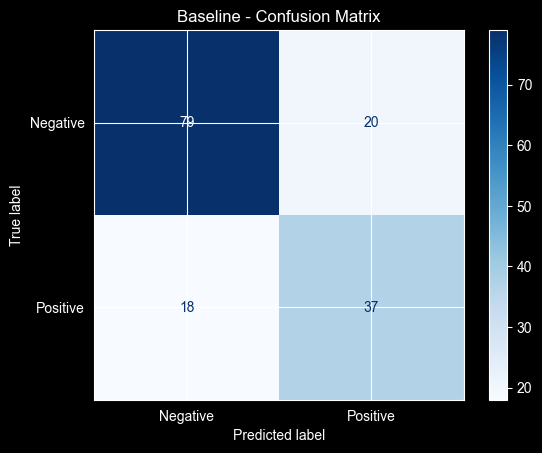

In [5]:
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

nb = NaiveBayes()
nb.fit(X_train_np, y_train_np)
predictions = nb.predict(X_test_np)

# accuracy
accuracy = np.mean(predictions == y_test_np) * 100
print(f"Accuracy: {accuracy :.2f}%")

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# classification report
print("Classification Report:")
print(classification_report(y_test_np, predictions))

# confusion matrix
cm = confusion_matrix(y_test_np, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title("Baseline - Confusion Matrix")
plt.show()

# Experiment A

Selected features: ['preg', 'plas', 'skin', 'mass', 'age']
Feature Selection Accuracy: 72.08%
              precision    recall  f1-score   support

           0       0.80      0.76      0.78        99
           1       0.60      0.65      0.63        55

    accuracy                           0.72       154
   macro avg       0.70      0.71      0.70       154
weighted avg       0.73      0.72      0.72       154



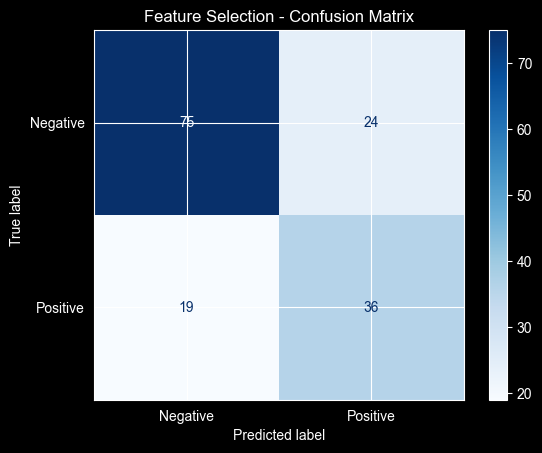

In [6]:
from sklearn.feature_selection import SelectKBest, f_classif

# select top 5
selector = SelectKBest(score_func=f_classif, k=5)
X_train_selected = selector.fit_transform(X_train_np, y_train_np)
X_test_selected = selector.transform(X_test_np)

selected_mask = selector.get_support()
selected_features = X.columns[selected_mask]
print("Selected features:", selected_features.tolist())

# train and eval
nb_fs = NaiveBayes()
nb_fs.fit(X_train_selected, y_train_np)
predictions_fs = nb_fs.predict(X_test_selected)

# accuracy
accuracy_fs = np.mean(predictions_fs == y_test_np) * 100
print(f"Feature Selection Accuracy: {accuracy_fs:.2f}%")

# classification report
print(classification_report(y_test_np, predictions_fs))

# confusion matrix
cm_fs = confusion_matrix(y_test_np, predictions_fs)
disp_fs = ConfusionMatrixDisplay(confusion_matrix=cm_fs, display_labels=['Negative', 'Positive'])
disp_fs.plot(cmap='Blues')
plt.title("Feature Selection - Confusion Matrix")
plt.show()

# Experiment B

In [8]:
import PCA

for k in range(1, 9):
    pca = PCA.PCA(k)
    pca.fit(X_train_np)
    X_train_pca = pca.transform(X_train_np)
    X_test_pca = pca.transform(X_test_np)

    nb_pca = NaiveBayes()
    nb_pca.fit(X_train_pca, y_train_np)
    predictions_pca = nb_pca.predict(X_test_pca)

    accuracy_pca = np.mean(predictions_pca == y_test_np) * 100
    print(f"k={k}: {accuracy_pca:.2f}%")

k=1: 68.18%
k=2: 75.97%
k=3: 75.97%
k=4: 75.32%
k=5: 75.32%
k=6: 77.27%
k=7: 75.97%
k=8: 77.27%
